<a href="https://colab.research.google.com/github/abdullahhadi9898/-indata-software-sentiment/blob/main/indata_sentiment_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#importing data from google drive to collab

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Cell 4 — Verify files are accessible
import os

# Update this path to match your actual folder name in Google Drive
DRIVE_PATH = '/content/drive/MyDrive/indata-project'

# List files in the folder
files = os.listdir(DRIVE_PATH)
print("Files found in your Google Drive folder:")
for f in files:
    size = os.path.getsize(f'{DRIVE_PATH}/{f}') / (1024**3)
    print(f"  {f}  —  {size:.2f} GB")

Files found in your Google Drive folder:
  Software.jsonl.gz  —  0.46 GB
  meta_Software.jsonl.gz  —  0.06 GB
  software_reviews_final.csv  —  0.03 GB
  software_reviews_final.gsheet  —  0.00 GB


In [16]:
# Cell 5 — Set file paths
REVIEW_FILE = '/content/drive/MyDrive/indata-project/Software.jsonl.gz'
META_FILE = '/content/drive/MyDrive/indata-project/meta_Software.jsonl.gz'
SAMPLE_SIZE = 20000  # 20k per star rating = 100k total

print("✅ File paths set")
print(f"   Review file : {REVIEW_FILE}")
print(f"   Meta file   : {META_FILE}")

✅ File paths set
   Review file : /content/drive/MyDrive/indata-project/Software.jsonl.gz
   Meta file   : /content/drive/MyDrive/indata-project/meta_Software.jsonl.gz


In [17]:
# Cell 6 — Load raw review data
import json
import gzip

print("Loading reviews... this will take a few minutes.")
print("You will see progress updates every 500,000 rows.\n")

reviews = []
with gzip.open(REVIEW_FILE, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            reviews.append(json.loads(line.strip()))
        except json.JSONDecodeError:
            continue

        if i % 500000 == 0 and i > 0:
            print(f"  Scanned {i:,} rows so far...")

df_raw = pd.DataFrame(reviews)

print(f"\n✅ Raw data loaded successfully")
print(f"   Total rows    : {df_raw.shape[0]:,}")
print(f"   Total columns : {df_raw.shape[1]}")
print(f"\nColumns found:")
print(df_raw.columns.tolist())

Loading reviews... this will take a few minutes.
You will see progress updates every 500,000 rows.

  Scanned 500,000 rows so far...
  Scanned 1,000,000 rows so far...
  Scanned 1,500,000 rows so far...
  Scanned 2,000,000 rows so far...
  Scanned 2,500,000 rows so far...
  Scanned 3,000,000 rows so far...
  Scanned 3,500,000 rows so far...
  Scanned 4,000,000 rows so far...
  Scanned 4,500,000 rows so far...

✅ Raw data loaded successfully
   Total rows    : 4,880,181
   Total columns : 10

Columns found:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


importing libraries

In [18]:
# ============================================================
# MASTER CELL — Run this once to set up everything
# Install → Import → Load → Sample → Clean
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'vaderSentiment', 'gensim', 'wordcloud', '-q'])

import json, gzip, re, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import defaultdict
import random

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# ── File paths ──────────────────────────────────────────────
REVIEW_FILE = '/content/drive/MyDrive/indata-project/Software.jsonl.gz'
META_FILE   = '/content/drive/MyDrive/indata-project/meta_Software.jsonl.gz'
SAMPLE_SIZE = 20000
SAVE_PATH   = '/content/drive/MyDrive/indata-project/software_reviews_final.csv'

print("✅ Libraries ready")
print("=" * 50)

# ── STEP 1: Load and sample simultaneously ───────────────────
print("STEP 1 — Loading and sampling...")
random.seed(42)
buckets = defaultdict(list)

with gzip.open(REVIEW_FILE, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            record = json.loads(line.strip())
        except json.JSONDecodeError:
            continue
        rating = record.get('rating')
        if rating not in [1.0, 2.0, 3.0, 4.0, 5.0]:
            continue
        bucket = buckets[rating]
        if len(bucket) < SAMPLE_SIZE:
            bucket.append(record)
        else:
            j = random.randint(0, i)
            if j < SAMPLE_SIZE:
                bucket[j] = record
        if i % 500000 == 0 and i > 0:
            print(f"  Scanned {i:,} rows...")

all_reviews = []
for rating, records in buckets.items():
    all_reviews.extend(records)

df = pd.DataFrame(all_reviews).reset_index(drop=True)
print(f"✅ Loaded: {len(df):,} rows")

# ── STEP 2: Clean and filter ─────────────────────────────────
print("\nSTEP 2 — Cleaning and filtering...")

COLS = ['rating', 'title', 'text', 'parent_asin',
        'timestamp', 'helpful_vote', 'verified_purchase']
df = df[COLS].copy()

before = len(df)
df = df[df['verified_purchase'] == True].reset_index(drop=True)
print(f"  Verified filter   : {before:,} → {len(df):,}")

before = len(df)
df = df[df['text'].notna() & (df['text'].str.strip() != '')].reset_index(drop=True)
print(f"  Empty text filter : {before:,} → {len(df):,}")

before = len(df)
df = df[df['text'].str.len() >= 20].reset_index(drop=True)
print(f"  Min length filter : {before:,} → {len(df):,}")

df['date']       = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')
df['helpful_vote'] = df['helpful_vote'].fillna(0).astype(int)

print(f"✅ Clean dataset: {len(df):,} rows")

# ── STEP 3: Load and join metadata ───────────────────────────
print("\nSTEP 3 — Loading metadata...")

meta = []
with gzip.open(META_FILE, 'rt', encoding='utf-8') as f:
    for line in f:
        try:
            meta.append(json.loads(line.strip()))
        except json.JSONDecodeError:
            continue

df_meta = pd.DataFrame(meta)
print(f"  Meta loaded: {len(df_meta):,} products")

META_COLS = ['parent_asin', 'title', 'store', 'price',
             'average_rating', 'rating_number']
meta_cols_exist = [c for c in META_COLS if c in df_meta.columns]
df_meta = df_meta[meta_cols_exist].drop_duplicates('parent_asin')

df = df.merge(df_meta, on='parent_asin', how='left')
df = df.rename(columns={'title_x': 'review_title', 'title_y': 'product_name'})

print(f"✅ Merged dataset: {len(df):,} rows, {df.shape[1]} columns")

# ── STEP 4: Save to Google Drive ─────────────────────────────
print("\nSTEP 4 — Saving to Google Drive...")
df.to_csv(SAVE_PATH, index=False)
size = os.path.getsize(SAVE_PATH) / (1024**2)
print(f"✅ Saved: {SAVE_PATH}")
print(f"   File size: {size:.1f} MB")

# ── FINAL SUMMARY ────────────────────────────────────────────
print("\n" + "=" * 50)
print("DATASET READY")
print("=" * 50)
print(f"Total reviews   : {len(df):,}")
print(f"Columns         : {df.shape[1]}")
print(f"Date range      : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique products : {df['parent_asin'].nunique():,}")
if 'store' in df.columns:
    print(f"Unique brands   : {df['store'].nunique():,}")
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())
print(f"\nColumns available:")
print(df.columns.tolist())

✅ Libraries ready
STEP 1 — Loading and sampling...
  Scanned 500,000 rows...
  Scanned 1,000,000 rows...
  Scanned 1,500,000 rows...
  Scanned 2,000,000 rows...
  Scanned 2,500,000 rows...
  Scanned 3,000,000 rows...
  Scanned 3,500,000 rows...
  Scanned 4,000,000 rows...
  Scanned 4,500,000 rows...
✅ Loaded: 100,000 rows

STEP 2 — Cleaning and filtering...
  Verified filter   : 100,000 → 94,135
  Empty text filter : 94,135 → 94,129
  Min length filter : 94,129 → 75,851
✅ Clean dataset: 75,851 rows

STEP 3 — Loading metadata...
  Meta loaded: 89,251 products
✅ Merged dataset: 75,851 rows, 16 columns

STEP 4 — Saving to Google Drive...
✅ Saved: /content/drive/MyDrive/indata-project/software_reviews_final.csv
   File size: 24.5 MB

DATASET READY
Total reviews   : 75,851
Columns         : 16
Date range      : 2000-05-25 → 2023-09-03
Unique products : 15,301
Unique brands   : 7,541

Rating distribution:
rating
1.0    14655
2.0    15574
3.0    14843
4.0    15680
5.0    15099
Name: count, dt

In [19]:
df = pd.read_csv('/content/drive/MyDrive/indata-project/software_reviews_final.csv')

In [20]:
print("Building text cleaning pipeline...")

# Set up tools
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

# Add custom stop words specific to software reviews
# These words appear in almost every review and add no topic signal
custom_stops = {
    'software', 'product', 'program', 'app', 'application',
    'use', 'used', 'using', 'work', 'works', 'worked',
    'get', 'got', 'one', 'also', 'would', 'could', 'even',
    'time', 'like', 'just', 'really', 'very', 'good', 'great',
    'bad', 'well', 'make', 'made', 'need', 'want', 'way',
    'much', 'many', 'lot', 'thing', 'things', 'purchase',
    'bought', 'buy', 'amazon', 'review', 'star', 'rating'
}
stop_words.update(custom_stops)

def clean_text(text):
    # Step 1 — lowercase
    text = str(text).lower()

    # Step 2 — remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3 — remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Step 4 — remove numbers and special characters
    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 5 — tokenise (split into individual words)
    tokens = text.split()

    # Step 6 — remove stop words and very short words
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    # Step 7 — lemmatise (convert to base form)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

print("Cleaning 75,851 reviews... this takes 2-3 minutes")

df['clean_text'] = df['text'].apply(clean_text)

# Remove rows where cleaning left nothing
before = len(df)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f"Rows after empty clean_text removal: {len(df):,}")

print(f"\n✅ Text cleaning complete")
print(f"\nOriginal text sample:")
print(df['text'].iloc[0][:200])
print(f"\nCleaned text sample:")
print(df['clean_text'].iloc[0][:200])

Building text cleaning pipeline...
Cleaning 75,851 reviews... this takes 2-3 minutes
Rows after empty clean_text removal: 75,593

✅ Text cleaning complete

Original text sample:
Uninstalled right away, was awkwardly set up

Cleaned text sample:
uninstalled right away awkwardly set


In [21]:
#VADER Sentiment Scoring
# Run on ORIGINAL text — not clean_text
# VADER needs punctuation, capitals, and exclamation marks

print("Running VADER sentiment scoring...")
print("Scoring 75,593 reviews... this takes 2-3 minutes\n")

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']

    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'

    return compound, label

# Apply to every review
df[['compound_score', 'sentiment_label']] = df['text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Create rating-based sentiment for comparison
def rating_to_sentiment(r):
    if r >= 4.0:
        return 'Positive'
    elif r <= 2.0:
        return 'Negative'
    else:
        return 'Neutral'

df['rating_sentiment'] = df['rating'].apply(rating_to_sentiment)

# Agreement analysis
df['vader_agrees'] = df['sentiment_label'] == df['rating_sentiment']

print("✅ VADER scoring complete")
print("\n── Sentiment Distribution ──────────────────")
sentiment_counts = df['sentiment_label'].value_counts()
total = len(df)
for label, count in sentiment_counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:8} : {bar} {count:,} ({pct:.1f}%)")

print("\n── VADER vs Star Rating Agreement ──────────")
agree_rate = df['vader_agrees'].mean() * 100
print(f"  Agreement rate : {agree_rate:.1f}%")
print(f"  Disagreement   : {100 - agree_rate:.1f}%")

print("\n── Disagreement Breakdown ───────────────────")
disagree = df[df['vader_agrees'] == False]
print(f"  Total disagreements: {len(disagree):,}")
print(f"\n  Where they disagree:")
cross = pd.crosstab(
    disagree['rating_sentiment'],
    disagree['sentiment_label'],
    margins=False
)
print(cross)

print("\n── Sample Reviews ───────────────────────────")
print("\nMost POSITIVE by VADER:")
top_pos = df.nlargest(1, 'compound_score')[['text', 'rating', 'compound_score']]
print(f"  Rating: {top_pos['rating'].values[0]} stars")
print(f"  Score : {top_pos['compound_score'].values[0]}")
print(f"  Text  : {top_pos['text'].values[0][:150]}")

print("\nMost NEGATIVE by VADER:")
top_neg = df.nsmallest(1, 'compound_score')[['text', 'rating', 'compound_score']]
print(f"  Rating: {top_neg['rating'].values[0]} stars")
print(f"  Score : {top_neg['compound_score'].values[0]}")
print(f"  Text  : {top_neg['text'].values[0][:150]}")

Running VADER sentiment scoring...
Scoring 75,593 reviews... this takes 2-3 minutes

✅ VADER scoring complete

── Sentiment Distribution ──────────────────
  Positive : ███████████████████████████████ 47,219 (62.5%)
  Negative : ████████████ 18,902 (25.0%)
  Neutral  : ██████ 9,472 (12.5%)

── VADER vs Star Rating Agreement ──────────
  Agreement rate : 55.3%
  Disagreement   : 44.7%

── Disagreement Breakdown ───────────────────
  Total disagreements: 33,816

  Where they disagree:
sentiment_label   Negative  Neutral  Positive
rating_sentiment                             
Negative                 0     5556     11470
Neutral               3780        0      9031
Positive              2046     1933         0

── Sample Reviews ───────────────────────────

Most POSITIVE by VADER:
  Rating: 5.0 stars
  Score : 0.9999
  Text  : I tried other evolutions and this one is the best!!!!!!!!😂😂😂😂😂😂😂😁😂😂😂😂😂😂😁😂😂😂😂💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💖💟💟💟💟💟💟👏👏👏👏👏👏👏💙💙💙💙💙💚💚💚💚💙💙💗💗💗💗💗💗💖💖💖💗💗💝💞

Most NEGATI

In [22]:
#Save progress and verify dataset

# Save updated dataframe with sentiment columns to Drive
SAVE_PATH = '/content/drive/MyDrive/indata-project/software_reviews_final.csv'
df.to_csv(SAVE_PATH, index=False)
print(f"✅ Progress saved to Google Drive")
print(f"   File: {SAVE_PATH}")

# Quick verification
print(f"\n── Dataset Status ───────────────────────────")
print(f"  Total rows     : {len(df):,}")
print(f"  Total columns  : {df.shape[1]}")
print(f"  Columns        : {df.columns.tolist()}")
print(f"\n── Columns added so far ─────────────────────")
print(f"  clean_text     : cleaned text for LDA")
print(f"  compound_score : VADER score -1.0 to +1.0")
print(f"  sentiment_label: Positive / Negative / Neutral")
print(f"  rating_sentiment: star rating converted to label")
print(f"  vader_agrees   : True if VADER matches star rating")
print(f"\n── Ready for Step 4: LDA Topic Modelling ────")

✅ Progress saved to Google Drive
   File: /content/drive/MyDrive/indata-project/software_reviews_final.csv

── Dataset Status ───────────────────────────
  Total rows     : 75,593
  Total columns  : 21
  Columns        : ['rating', 'review_title', 'text', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'date', 'year', 'month', 'year_month', 'product_name', 'store', 'price', 'average_rating', 'rating_number', 'clean_text', 'compound_score', 'sentiment_label', 'rating_sentiment', 'vader_agrees']

── Columns added so far ─────────────────────
  clean_text     : cleaned text for LDA
  compound_score : VADER score -1.0 to +1.0
  sentiment_label: Positive / Negative / Neutral
  rating_sentiment: star rating converted to label
  vader_agrees   : True if VADER matches star rating

── Ready for Step 4: LDA Topic Modelling ────


In [23]:
# Prepare text for LDA
# Split dataset into negative and positive reviews
# Then convert clean_text into the format Gensim needs

print("Preparing text for LDA...")

# Split by sentiment
negative_reviews = df[df['sentiment_label'] == 'Negative']['clean_text'].tolist()
positive_reviews = df[df['sentiment_label'] == 'Positive']['clean_text'].tolist()
print(f"  Negative reviews : {len(negative_reviews):,}")
print(f"  Positive reviews : {len(positive_reviews):,}")

# Tokenise — convert each review string into a list of words
# LDA needs list of lists — each review is a list of words
negative_tokens = [text.split() for text in negative_reviews]
positive_tokens = [text.split() for text in positive_reviews]

print(f"\n  Example negative tokens:")
print(f"  {negative_tokens[0][:10]}")
print(f"\n  Example positive tokens:")
print(f"  {positive_tokens[0][:10]}")

# Build dictionary for negative reviews
# Maps every unique word to an ID number
dict_neg = corpora.Dictionary(negative_tokens)
print(f"\n  Negative vocabulary size before filtering: {len(dict_neg):,} words")

# Remove extremes — words too rare or too common
dict_neg.filter_extremes(no_below=10, no_above=0.5)
print(f"  Negative vocabulary size after filtering : {len(dict_neg):,} words")

# Build dictionary for positive reviews
dict_pos = corpora.Dictionary(positive_tokens)
print(f"\n  Positive vocabulary size before filtering: {len(dict_pos):,} words")
dict_pos.filter_extremes(no_below=10, no_above=0.5)
print(f"  Positive vocabulary size after filtering : {len(dict_pos):,} words")

# Build corpus — convert each review to bag of words format
# Each review becomes a list of (word_id, word_count) pairs
corpus_neg = [dict_neg.doc2bow(tokens) for tokens in negative_tokens]
corpus_pos = [dict_pos.doc2bow(tokens) for tokens in positive_tokens]

print(f"\n  Example bag of words (negative review 1):")
print(f"  {corpus_neg[0][:5]}")
print(f"  Meaning: (word_id, count) pairs")

print(f"\n✅ LDA preparation complete")
print(f"  Negative corpus : {len(corpus_neg):,} documents")
print(f"  Positive corpus : {len(corpus_pos):,} documents")

Preparing text for LDA...
  Negative reviews : 18,902
  Positive reviews : 47,219

  Example negative tokens:
  ['uninstalled', 'right', 'away', 'awkwardly', 'set']

  Example positive tokens:
  ['unfortunately', 'cant', 'play', 'newer', 'version', 'computer', 'love', 'son', 'thought', 'try']

  Negative vocabulary size before filtering: 18,105 words
  Negative vocabulary size after filtering : 2,676 words

  Positive vocabulary size before filtering: 32,454 words
  Positive vocabulary size after filtering : 4,684 words

  Example bag of words (negative review 1):
  [(0, 1), (1, 1), (2, 1), (3, 1)]
  Meaning: (word_id, count) pairs

✅ LDA preparation complete
  Negative corpus : 18,902 documents
  Positive corpus : 47,219 documents


In [24]:
# Run LDA on NEGATIVE reviews
# Finding complaint topics — what unhappy customers write about

print("Running LDA on negative reviews...")
print("Finding 6 complaint topics...")
print("This takes 3-5 minutes. Do not click anything.\n")

NUM_TOPICS = 6

lda_negative = LdaModel(
    corpus=corpus_neg,
    id2word=dict_neg,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto',
    minimum_probability=0.01
)

print("✅ LDA complete on negative reviews")
print("\n── Raw Topic Output ─────────────────────────")
print("(These are the words LDA found — you will name each topic)\n")

for idx, topic in lda_negative.print_topics(num_words=10):
    print(f"Topic {idx}:")
    print(f"  {topic}")
    print()

Running LDA on negative reviews...
Finding 6 complaint topics...
This takes 3-5 minutes. Do not click anything.

✅ LDA complete on negative reviews

── Raw Topic Output ─────────────────────────
(These are the words LDA found — you will name each topic)

Topic 0:
  0.013*"cant" + 0.011*"find" + 0.010*"back" + 0.010*"every" + 0.009*"difficult" + 0.008*"see" + 0.008*"screen" + 0.008*"try" + 0.008*"problem" + 0.008*"doesnt"

Topic 1:
  0.045*"show" + 0.040*"watch" + 0.039*"money" + 0.035*"pay" + 0.027*"free" + 0.021*"movie" + 0.021*"worth" + 0.019*"commercial" + 0.015*"channel" + 0.015*"limited"

Topic 2:
  0.076*"fire" + 0.069*"kindle" + 0.027*"phone" + 0.021*"wont" + 0.021*"video" + 0.021*"tablet" + 0.020*"tried" + 0.020*"sure" + 0.019*"device" + 0.018*"download"

Topic 3:
  0.131*"game" + 0.053*"dont" + 0.033*"play" + 0.028*"didnt" + 0.024*"fun" + 0.020*"level" + 0.014*"boring" + 0.014*"ad" + 0.014*"playing" + 0.013*"know"

Topic 4:
  0.020*"computer" + 0.018*"problem" + 0.016*"window"

In [25]:
# Run LDA on POSITIVE reviews
# Finding praise topics — what happy customers write about

print("Running LDA on positive reviews...")
print("Finding 6 praise topics...")
print("This takes 3-5 minutes. Do not click anything.\n")

lda_positive = LdaModel(
    corpus=corpus_pos,
    id2word=dict_pos,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto',
    minimum_probability=0.01
)

print("✅ LDA complete on positive reviews")
print("\n── Raw Topic Output ─────────────────────────")
print("(These are the words LDA found — you will name each topic)\n")

for idx, topic in lda_positive.print_topics(num_words=10):
    print(f"Topic {idx}:")
    print(f"  {topic}")
    print()

Running LDA on positive reviews...
Finding 6 praise topics...
This takes 3-5 minutes. Do not click anything.

✅ LDA complete on positive reviews

── Raw Topic Output ─────────────────────────
(These are the words LDA found — you will name each topic)

Topic 0:
  0.078*"kindle" + 0.055*"fire" + 0.040*"phone" + 0.034*"device" + 0.033*"apps" + 0.028*"tablet" + 0.025*"screen" + 0.023*"please" + 0.023*"fix" + 0.016*"stick"

Topic 1:
  0.019*"version" + 0.016*"year" + 0.011*"update" + 0.011*"new" + 0.010*"problem" + 0.008*"download" + 0.008*"computer" + 0.007*"since" + 0.007*"ive" + 0.007*"still"

Topic 2:
  0.015*"see" + 0.014*"word" + 0.012*"find" + 0.012*"know" + 0.011*"option" + 0.009*"doesnt" + 0.009*"picture" + 0.008*"dont" + 0.008*"feature" + 0.007*"look"

Topic 3:
  0.054*"tax" + 0.031*"color" + 0.030*"state" + 0.022*"return" + 0.020*"turbotax" + 0.017*"form" + 0.017*"turbo" + 0.013*"block" + 0.013*"beat" + 0.012*"adult"

Topic 4:
  0.087*"game" + 0.029*"play" + 0.027*"fun" + 0.016*"

In [3]:
# ============================================================
# FULL RESTART CELL
# Run this single cell after any session reset
# Loads CSV → rebuilds text pipeline → reruns LDA → ready
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'vaderSentiment', 'gensim', 'wordcloud', '-q'])

import json, gzip, re, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import defaultdict
import random

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Mount Drive and load CSV ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

SAVE_PATH = '/content/drive/MyDrive/indata-project/software_reviews_final.csv'
df = pd.read_csv(SAVE_PATH)
print(f"✅ Dataset loaded: {len(df):,} rows, {df.shape[1]} columns")

# ── Rebuild clean_text if missing ────────────────────────────
if 'clean_text' not in df.columns:
    print("Rebuilding clean_text column...")
    stop_words = set(stopwords.words('english'))
    custom_stops = {
        'software','product','program','app','application',
        'use','used','using','work','works','worked',
        'get','got','one','also','would','could','even',
        'time','like','just','really','very','good','great',
        'bad','well','make','made','need','want','way',
        'much','many','lot','thing','things','purchase',
        'bought','buy','amazon','review','star','rating'
    }
    stop_words.update(custom_stops)
    lemmatizer = WordNetLemmatizer()

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        tokens = text.split()
        tokens = [w for w in tokens
                  if w not in stop_words and len(w) > 2]
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
        return ' '.join(tokens)

    df['clean_text'] = df['text'].apply(clean_text)
    df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
    print(f"✅ clean_text rebuilt: {len(df):,} rows")
else:
    print("✅ clean_text already in dataset")

# ── Rebuild LDA inputs ───────────────────────────────────────
print("\nRebuilding LDA corpus and dictionary...")

negative_tokens = [t.split() for t in
                   df[df['sentiment_label']=='Negative']['clean_text'].tolist()]
positive_tokens = [t.split() for t in
                   df[df['sentiment_label']=='Positive']['clean_text'].tolist()]

dict_neg = corpora.Dictionary(negative_tokens)
dict_neg.filter_extremes(no_below=10, no_above=0.5)
corpus_neg = [dict_neg.doc2bow(t) for t in negative_tokens]

dict_pos = corpora.Dictionary(positive_tokens)
dict_pos.filter_extremes(no_below=10, no_above=0.5)
corpus_pos = [dict_pos.doc2bow(t) for t in positive_tokens]

print(f"✅ Corpus ready")
print(f"   Negative: {len(corpus_neg):,} docs")
print(f"   Positive: {len(corpus_pos):,} docs")

# ── Rerun LDA ────────────────────────────────────────────────
print("\nRunning LDA on negative reviews...")
NUM_TOPICS = 6
lda_negative = LdaModel(
    corpus=corpus_neg, id2word=dict_neg,
    num_topics=NUM_TOPICS, random_state=42,
    passes=15, alpha='auto', eta='auto',
    minimum_probability=0.01
)
print("✅ LDA negative complete")

print("Running LDA on positive reviews...")
lda_positive = LdaModel(
    corpus=corpus_pos, id2word=dict_pos,
    num_topics=NUM_TOPICS, random_state=42,
    passes=15, alpha='auto', eta='auto',
    minimum_probability=0.01
)
print("✅ LDA positive complete")

# ── Topic names ──────────────────────────────────────────────
complaint_topics = {
    0: "Usability and Navigation Problems",
    1: "Paid Content and Value for Money",
    2: "Device Compatibility and Download Issues",
    3: "Mobile Game Quality and Ads",
    4: "Installation Errors and Customer Support",
    5: "Annual Updates and Subscription Pricing"
}
praise_topics = {
    0: "Amazon Device and App Experience",
    1: "Software Updates and Improvements",
    2: "Feature Discovery and Usability",
    3: "Tax Software Satisfaction",
    4: "Enjoyable Gaming Experience",
    5: "Streaming and Media Content Satisfaction"
}

print("\n✅ Everything ready — continue from Cell 15")
print(f"   df shape      : {df.shape}")
print(f"   corpus_neg    : {len(corpus_neg):,} docs")
print(f"   corpus_pos    : {len(corpus_pos):,} docs")
print(f"   lda_negative  : ready")
print(f"   lda_positive  : ready")

Mounted at /content/drive
✅ Dataset loaded: 75,593 rows, 21 columns
✅ clean_text already in dataset

Rebuilding LDA corpus and dictionary...
✅ Corpus ready
   Negative: 18,902 docs
   Positive: 47,219 docs

Running LDA on negative reviews...
✅ LDA negative complete
Running LDA on positive reviews...
✅ LDA positive complete

✅ Everything ready — continue from Cell 15
   df shape      : (75593, 21)
   corpus_neg    : 18,902 docs
   corpus_pos    : 47,219 docs
   lda_negative  : ready
   lda_positive  : ready


In [4]:
# Save topic names and assign dominant topic per review

# Named topics — complaint
complaint_topics = {
    0: "Usability and Navigation Problems",
    1: "Paid Content and Value for Money",
    2: "Device Compatibility and Download Issues",
    3: "Mobile Game Quality and Ads",
    4: "Installation Errors and Customer Support",
    5: "Annual Updates and Subscription Pricing"
}

# Named topics — praise
praise_topics = {
    0: "Amazon Device and App Experience",
    1: "Software Updates and Improvements",
    2: "Feature Discovery and Usability",
    3: "Tax Software Satisfaction",
    4: "Enjoyable Gaming Experience",
    5: "Streaming and Media Content Satisfaction"
}

print("Assigning dominant topic to each review...")

def get_dominant_topic(corpus, lda_model, topic_names):
    dominant = []
    for bow in corpus:
        topics = lda_model.get_document_topics(bow)
        if topics:
            top = max(topics, key=lambda x: x[1])
            dominant.append(topic_names[top[0]])
        else:
            dominant.append("Unknown")
    return dominant

# Assign to negative reviews
neg_indices = df[df['sentiment_label'] == 'Negative'].index.tolist()
pos_indices = df[df['sentiment_label'] == 'Positive'].index.tolist()

neg_topics = get_dominant_topic(corpus_neg, lda_negative, complaint_topics)
pos_topics = get_dominant_topic(corpus_pos, lda_positive, praise_topics)

# Add to dataframe
df.loc[neg_indices, 'dominant_topic'] = neg_topics
df.loc[pos_indices, 'dominant_topic'] = pos_topics
df['dominant_topic'] = df['dominant_topic'].fillna('Neutral — No dominant topic')

print("✅ Topics assigned")
print("\n── Complaint Topic Distribution ─────────────")
neg_dist = (df[df['sentiment_label'] == 'Negative']
            ['dominant_topic'].value_counts())
total_neg = neg_dist.sum()
for topic, count in neg_dist.items():
    pct = count / total_neg * 100
    print(f"  {topic[:45]:45} : {count:,} ({pct:.1f}%)")

print("\n── Praise Topic Distribution ────────────────")
pos_dist = (df[df['sentiment_label'] == 'Positive']
            ['dominant_topic'].value_counts())
total_pos = pos_dist.sum()
for topic, count in pos_dist.items():
    pct = count / total_pos * 100
    print(f"  {topic[:45]:45} : {count:,} ({pct:.1f}%)")

# Save updated dataframe
df.to_csv(SAVE_PATH, index=False)
print(f"\n✅ Saved to Google Drive with topic assignments")

Assigning dominant topic to each review...
✅ Topics assigned

── Complaint Topic Distribution ─────────────
  Usability and Navigation Problems             : 10,059 (53.2%)
  Mobile Game Quality and Ads                   : 4,710 (24.9%)
  Device Compatibility and Download Issues      : 1,260 (6.7%)
  Installation Errors and Customer Support      : 1,128 (6.0%)
  Paid Content and Value for Money              : 1,118 (5.9%)
  Annual Updates and Subscription Pricing       : 627 (3.3%)

── Praise Topic Distribution ────────────────
  Enjoyable Gaming Experience                   : 39,045 (82.7%)
  Software Updates and Improvements             : 5,246 (11.1%)
  Feature Discovery and Usability               : 2,258 (4.8%)
  Streaming and Media Content Satisfaction      : 385 (0.8%)
  Amazon Device and App Experience              : 241 (0.5%)
  Tax Software Satisfaction                     : 44 (0.1%)

✅ Saved to Google Drive with topic assignments


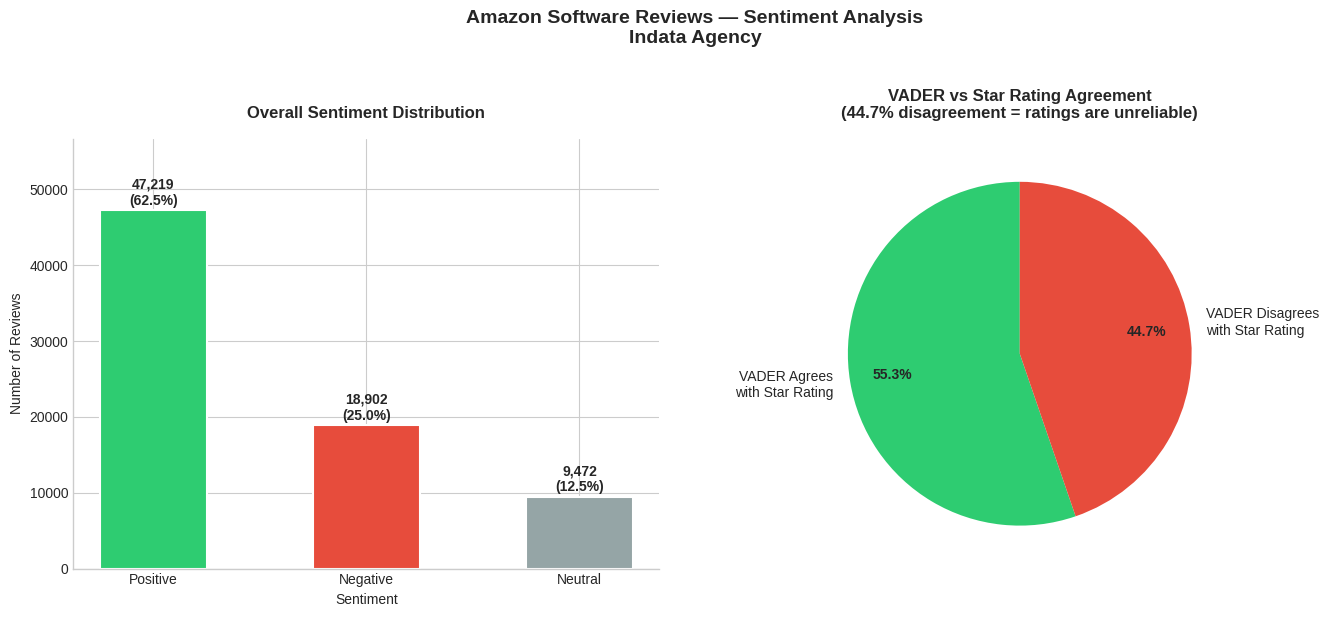

✅ Chart 1 saved


In [5]:
# Cell 16 — Chart 1: Sentiment Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Amazon Software Reviews — Sentiment Analysis\nIndata Agency',
             fontsize=14, fontweight='bold', y=1.02)

# ── Left chart: Sentiment distribution bar chart ─────────────
sentiment_counts = df['sentiment_label'].value_counts()
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
bar_colors = [colors[s] for s in sentiment_counts.index]

bars = axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add count and percentage labels on bars
for bar, (label, count) in zip(bars, sentiment_counts.items()):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )

axes[0].set_title('Overall Sentiment Distribution',
                  fontweight='bold', fontsize=12, pad=15)
axes[0].set_xlabel('Sentiment', fontsize=10)
axes[0].set_ylabel('Number of Reviews', fontsize=10)
axes[0].set_ylim(0, max(sentiment_counts.values) * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right chart: VADER vs Star rating agreement ──────────────
agree_data = df['vader_agrees'].value_counts()
agree_colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    agree_data.values,
    labels=['VADER Agrees\nwith Star Rating',
            'VADER Disagrees\nwith Star Rating'],
    colors=agree_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

axes[1].set_title('VADER vs Star Rating Agreement\n(44.7% disagreement = ratings are unreliable)',
                  fontweight='bold', fontsize=12, pad=15)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/indata-project/chart1_sentiment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")